# Elife Paper 
## Figure 2: Success of the model
- A. Joing spectrogram of 4 syllables
- B. Trajectory plots for 4 syllables
- C. Detailed trajectory plot for 1 syllable
- D. Creating artifical landscapes with different number of distractors

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
from dual_pathway_model.plotting_functions import *
import time

%load_ext autoreload


Base parameters loaded from params.yaml
Testing
Plotting colors safely loaded


In [2]:
%autoreload 2
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
from dual_pathway_model.plotting_functions import *

In [3]:
save_figs=False

### A. Song Spectrogram - 4 syllables joint plot

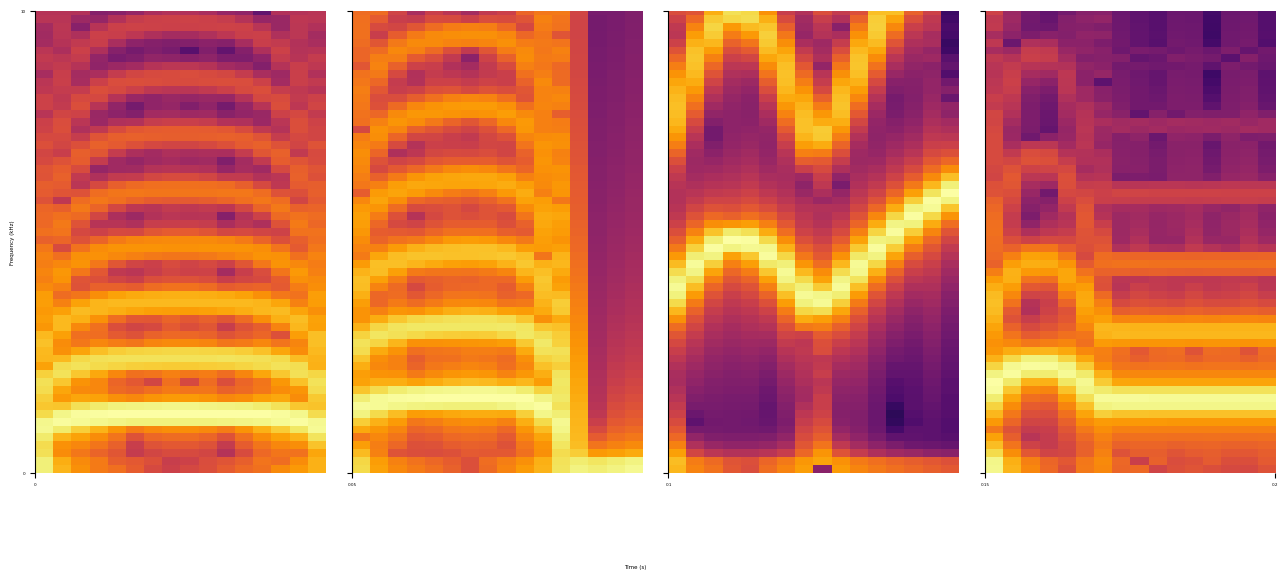

In [4]:
## Syrinx Spectrogram
# np.random.seed(100)
# Parameters
gamma = 12000 

duration = 0.050 #s
dt = 1/44100 #s  #* 0.1 #1.e-4

Amp = 10

# Trachea parameters
r=-0.9
v=350*100
L=1.9
tau_0=2*L/v # Propagation time along trachea
tau_n=int(tau_0/dt)
# ks = np.linspace(0.16,0.52, 10)
# ps = np.linspace(1852,2084, 10)

# Track position and velocity 
nt = int(duration/dt)
X = np.zeros(nt)          # Labial position
Y = np.zeros(nt)          # Velocity

def sigmoid(x):
      return 1 / (1 + np.exp(-x))

def syrinxODE(t, y):
    ''' ODEs used in Amador paper'''
    
    y0, y1 = y
    dydt = [y1,
         -Pressure(t)*(gamma**2) - Tension(t)*(gamma**2)*y0 - (gamma**2)*(y0**3) - gamma*(y0**2)*y1 + (gamma**2)*(y0**2) - gamma*y0*y1
           ]
    return dydt

# RC4
# syllable 1
syllable_array = [1,2,3,4]
P_t_list = []  # <— add before the syllable loop




for syllable in syllable_array:
    if syllable == 1:
        def Tension(t):
            """ Generalised exponential waveform """
            return   .3 - .2*np.exp(-200*t) -.00001 * np.exp(200*t) 

        
        def Pressure(t):
            """ Constant """
            return 0.04*np.sin((duration/2 + t)*np.pi*10) + 0.05
    # RC5 - test
    elif syllable == 2:
        # syllable 2
        def Tension(t):
            """ Generalised exponential waveform """
            Tc = 1#2/3
            return   .3 - .2*np.exp(-Tc*3*100*t) -.00001 * np.exp(Tc*3*100*t) 

        def Pressure(t):
            """ Constant """
            tp = 0.2
            return tp*np.sin((duration/2 + t)*np.pi*10) + 0.05
    elif syllable == 3:
        # syllable 3
        def Tension(t):
            """
                Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
                Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
                Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
            """
            scale = 1
            if isinstance(t, float):
                if t <= duration*scale/2: 
                    return 5*np.sin(t*np.pi*40/scale) + 0.6 # old amp 0.1
                elif t <= duration*scale: 
                    return 10*np.sin((t-duration*scale/2)*np.pi*15/scale) + 0.6 # old amp 0.2
                else: 
                    return 0.0 + 0*t
            elif isinstance(t, np.ndarray):
                Tension1 = 5*np.sin(t*np.pi*40/scale) + 0.6 # old amp 0.1
                Tension2 = 10*np.sin(t*np.pi*15/scale) + 0.6 # old amp 0.2
                Tension3 = 0.0 + 0*t
                return np.concatenate((Tension1[:int(np.ceil(t.size*scale/2))], Tension2[:int(t.size*scale-t.size*scale/2)], Tension3[:int(t.size-t.size*scale)]))        
        
        def Pressure(t):
            """ Pressure = 0.02 * np.ones((nt)) """
            return np.ones((np.asarray(t).shape)) * 2 # old amp 0.16
    elif syllable == 4:
        # syllable 4
        def Tension(t):
            """
                Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
                Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
                Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
            """
            scale = 0.4
            if isinstance(t, float):
                if t <= duration*scale: 
                    return 0.8*np.sin(t*np.pi*20/scale) + 0.6 # old amp 0.1
                else: 
                    return t*0 + 0.6 # old amp 0.2
            elif isinstance(t, np.ndarray):
                Tension1 = 0.8*np.sin(t*np.pi*20/scale) + 0.6 # old amp 0.1
                Tension2 = t* 0 + 0.6 # old amp 0.2
                return np.concatenate((Tension1[:int(np.ceil(t.size*scale))], Tension2[:int(t.size-t.size*scale)]))
            
        def Pressure(t):
            """ Pressure = 0.02 * np.ones((nt)) """
            return np.ones((np.asarray(t).shape)) * 0.01
            
    elif syllable == 5:
        # syllable 5
        def Tension(t):
            """ Tension = 0.2 * np.ones((nt)) """
            return np.ones((np.asarray(t).shape)) * 0.2
            
        def Pressure(t):
            """ Pressure = 0.1 * np.ones((nt)) """
            return np.ones((np.asarray(t).shape)) * 0.1
    elif syllable == 6:
        # syllable 6
        def Tension(t):
            """
                Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
                Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
                Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
            """
            if isinstance(t, float):
                if t <= duration/2: return 0.1*np.sin(t*np.pi*40) + 0.6
                else: return 0.2*np.sin((t-duration/2)*np.pi*15) + 0.6
            elif isinstance(t, np.ndarray):
                Tension1 = 0.1*np.sin(t*np.pi*40) + 0.6
                Tension2 = 0.2*np.sin(t*np.pi*15) + 0.6
                return np.concatenate((Tension1[:int(np.ceil(t.size/2))], Tension2[:int(t.size-t.size/2)]))
            
        def Pressure(t):
            """ Pressure = 0.01*np.sin(sin_t*np.pi*2*100) + 0.02 """
            return 0.01*np.sin(t*np.pi*2*100) + 0.02
        

    solution = solve_ivp(syrinxODE, [0, duration], [1, 1], method = "RK45", t_eval = np.linspace(0,duration,nt), rtol = 1e-8, atol = 1e-8)
    # Extract labial position (X) and velocity (Y)
    X = solution['y'][0]
    Y = solution['y'][1]
    # Transform into song
    time_x = np.linspace(0, duration, nt)
    song = Amp * Pressure(time_x) * Y
    ## Trachea from Darshan, et. al. https://doi.org/10.1038/ncomms15415

    # Input to trachea = output of syrinx
    y0 = song.T

    # To generate pressure output from trachea
    P_i=np.zeros((len(y0)))

    # See Fig 1 in Amador paper. Round-about way to implement that.
    Buffer = queue.Queue()
    for i in np.arange(tau_n):
        Buffer.put(np.random.random())

    for i in np.arange(len(y0)):
        P_i[i] = y0[i] - r*Buffer.get();      
        # update_buffer
        Buffer.put(P_i[i])

    # P_tr from P_in (ref Amador paper)
    BufferB=np.zeros((tau_n))
    P_tmp= np.concatenate((BufferB, P_i))
    P_t=(1-r)*P_tmp[:-tau_n]
    # ... inside your syllable loop, after computing P_t ...
    P_t_list.append(P_t.copy())
    time_x = np.linspace(0, duration, nt)



# Parameters for panel width and labeling step
seg = 0.05  # each subplot spans 0.05 s

figure, axes = plt.subplots(
    1, len(syllable_array),
    figsize=(4*len(syllable_array), 6),
    sharey=True, sharex=False,                 # sharey, but NOT sharex
    gridspec_kw={'wspace': 0.09}               # tight horizontal spacing
)

# Ensure axes is always a list, even for single subplot
if len(syllable_array) == 1:
    axes = [axes]

# Store spectrograms for each syllable
spectrograms = []

def fmt_tick(x):
    s = f"{x:.2f}".rstrip('0').rstrip('.')
    return s

for i, syllable in enumerate(syllable_array):
    # time window this panel represents in the global timeline
    x0 = i * seg
    x1 = (i + 1) * seg

    # pick the right pressure trace for this syllable
    P_src = P_t_list[i]  # assumes you appended in the simulation loop

    # Generate spectrogram positioned in the global time coordinates
    spectrumP, freqsP, t_bins, im = axes[i].specgram(
        P_src, Fs=1/dt, NFFT=256, noverlap=128,
        xextent=[x0, x1], cmap='inferno'
    )

    # Store spectrogram data
    spectrograms.append({
        "syllable": syllable,
        "spectrum": spectrumP,
        "freqs": freqsP,
        "time": t_bins,
        "image": im,
        "xrange": (x0, x1),
        "P_t": P_src
    })

    # Configure each subplot

    # axes[i].set_title(f'Syllable:{syllable}', fontsize=30)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_visible(False)
    axes[i].set_ylim(0, 10000)
    axes[i].set_xlim(x0, x1)
    # axes[i].set_yticklabels

    # ✅ Global-style ticks:
    # Only left edge ticks, except last panel shows both left+right
    if i < len(syllable_array) - 1:
        axes[i].set_xticks([x0])
        axes[i].set_xticklabels([fmt_tick(x0)])
    else:
        axes[i].set_xticks([x0, x1])
        axes[i].set_xticklabels([fmt_tick(x0), fmt_tick(x1)])

    # Y ticks
    axes[i].set_yticks([0, 10000])
    if i == 0:
        axes[i].set_yticklabels([0, 10])
    # else:
        # axes[i].set_yticklabels([])  # cleaner, contiguous look

    axes[i].tick_params(labelsize=3)
# # After the for loop ends (all syllables plotted) ...

# # Add one shared colorbar for the spectrograms
# cbar = figure.colorbar(
#     spectrograms[0]["image"],    # use the first specgram’s image handle
#     ax=axes,
#     orientation='vertical',
#     fraction=0.02,               # size of colorbar
#     pad=0.04                     # distance from plots
# )

# cbar.set_label("Power (dB)", fontsize=20)
# cbar.ax.tick_params(labelsize=15)

# Set labels only on the leftmost subplot
axes[0].set_ylabel('Frequency (kHz)', fontsize=4)
figure.supxlabel('Time (s)', fontsize=4, y = -0.05)
# plt.tight_layout()
# figure.subplots_adjust(wspace=0.1)  # extra-tight spacing between panels
plt.show()


In [5]:
def _get_syrinx_controls(syllable, duration, tension_offset = 0, pressure_offset = 0):
    """Return Tension(t), Pressure(t) functions for the requested syllable."""
    if syllable == 1:
        def Tension(t):
            return 0.3 - 0.2 * np.exp(-200 * t) - 0.00001 * np.exp(200 * t) + tension_offset

        def Pressure(t):
            return 0.04 * np.sin((duration / 2 + t) * np.pi * 10) + 0.05 + pressure_offset

    elif syllable == 2:
        def Tension(t):
            Tc = 1
            return 0.3 - 0.2 * np.exp(-Tc * 3 * 100 * t) - 0.00001 * np.exp(Tc * 3 * 100 * t) + tension_offset

        def Pressure(t):
            tp = 0.2
            return tp * np.sin((duration / 2 + t) * np.pi * 10) + 0.05 + pressure_offset

    elif syllable == 3:
        def Tension(t):
            scale = 1
            t_arr = np.asarray(t)
            if t_arr.ndim == 0:
                t_val = float(t_arr)
                if t_val <= duration * scale / 2:
                    return 5 * np.sin(t_val * np.pi * 40 / scale) + 0.6 + tension_offset
                if t_val <= duration * scale:
                    return 10 * np.sin((t_val - duration * scale / 2) * np.pi * 15 / scale) + 0.6 + tension_offset
                return 0.0 + tension_offset

            T1 = 5 * np.sin(t_arr * np.pi * 40 / scale) + 0.6 + tension_offset
            T2 = 10 * np.sin(t_arr * np.pi * 15 / scale) + 0.6 + tension_offset
            T3 = np.zeros_like(t_arr) + tension_offset
            n1 = int(np.ceil(t_arr.size * scale / 2))
            n2 = int(t_arr.size * scale - t_arr.size * scale / 2)
            n3 = int(t_arr.size - t_arr.size * scale)
            return np.concatenate((T1[:n1], T2[:n2], T3[:n3]))

        def Pressure(t):
            return np.ones(np.asarray(t).shape) * 2 + pressure_offset

    elif syllable == 4:
        def Tension(t):
            scale = 0.4
            t_arr = np.asarray(t)
            if t_arr.ndim == 0:
                t_val = float(t_arr)
                if t_val <= duration * scale:
                    return 0.8 * np.sin(t_val * np.pi * 20 / scale) + 0.6 + tension_offset
                return 0.6  + tension_offset

            T1 = 0.8 * np.sin(t_arr * np.pi * 20 / scale) + 0.6 + tension_offset
            T2 = np.zeros_like(t_arr) + 0.6 + tension_offset
            n1 = int(np.ceil(t_arr.size * scale))
            n2 = int(t_arr.size - t_arr.size * scale)
            return np.concatenate((T1[:n1], T2[:n2]))

        def Pressure(t):
            return np.ones(np.asarray(t).shape) * 0.01 + pressure_offset

    elif syllable == 5:
        def Tension(t):
            return np.ones(np.asarray(t).shape) * 0.2 + tension_offset

        def Pressure(t):
            return np.ones(np.asarray(t).shape) * 0.1 + pressure_offset

    elif syllable == 6:
        def Tension(t):
            t_arr = np.asarray(t)
            if t_arr.ndim == 0:
                t_val = float(t_arr)
                if t_val <= duration / 2:
                    return 0.1 * np.sin(t_val * np.pi * 40) + 0.6 + tension_offset
                return 0.2 * np.sin((t_val - duration / 2) * np.pi * 15) + 0.6 + tension_offset

            T1 = 0.1 * np.sin(t_arr * np.pi * 40) + 0.6 + tension_offset
            T2 = 0.2 * np.sin(t_arr * np.pi * 15) + 0.6 + tension_offset
            n1 = int(np.ceil(t_arr.size / 2))
            n2 = int(t_arr.size - t_arr.size / 2)
            return np.concatenate((T1[:n1], T2[:n2]))

        def Pressure(t):
            return 0.01 * np.sin(np.asarray(t) * np.pi * 2 * 100) + 0.02 + pressure_offset

    else:
        raise ValueError(f"Unsupported syllable: {syllable}. Use 1-6.")

    return Tension, Pressure


def make_syrinx_spectrograms(
    syll=None,
    syll_array=None,
    tension_offset=0,
    pressure_offset=0,
    *,
    gamma=12000,
    duration=0.050,
    dt=1 / 44100,
    amp=10,
    r=-0.9,
    v=350 * 100,
    L=1.9,
    nfft=256,
    noverlap=128,
    cmap="inferno",
    seg=0.05,
    figsize_per_panel=(4, 6),
    show=True,
    random_seed=None,
):
    """
    Build joint spectrogram figure for one or many syllables.

    Parameters
    ----------
    syll : int or None
        Single syllable index (1-6). If provided, overrides syll_array.
    syll_array : iterable[int] or None
        List/tuple/array of syllable indices.

    Returns
    -------
    dict with keys: figure, axes, traces, spectrograms
    """
    if syll is not None:
        syllables = [int(syll)]
    elif syll_array is not None:
        syllables = [int(s) for s in np.atleast_1d(syll_array).tolist()]
    else:
        syllables = [1, 2, 3, 4]

    if random_seed is not None:
        np.random.seed(random_seed)

    tau_0 = 2 * L / v
    tau_n = int(tau_0 / dt)
    nt = int(duration / dt)
    t_eval = np.linspace(0, duration, nt)

    traces = []

    for syllable in syllables:
        Tension, Pressure = _get_syrinx_controls(syllable, duration, tension_offset, pressure_offset)

        def syrinx_ode(t, y):
            y0, y1 = y
            dydt = [
                y1,
                -Pressure(t) * (gamma ** 2)
                - Tension(t) * (gamma ** 2) * y0
                - (gamma ** 2) * (y0 ** 3)
                - gamma * (y0 ** 2) * y1
                + (gamma ** 2) * (y0 ** 2)
                - gamma * y0 * y1,
            ]
            return dydt

        solution = solve_ivp(
            syrinx_ode,
            [0, duration],
            [1, 1],
            method="RK45",
            t_eval=t_eval,
            rtol=1e-8,
            atol=1e-8,
        )

        Y = solution["y"][1]
        song = amp * Pressure(t_eval) * Y
        y0 = song.T

        P_i = np.zeros(len(y0))
        buffer = queue.Queue()
        for _ in range(tau_n):
            buffer.put(np.random.random())

        for i in range(len(y0)):
            P_i[i] = y0[i] - r * buffer.get()
            buffer.put(P_i[i])

        buffer_b = np.zeros(tau_n)
        p_tmp = np.concatenate((buffer_b, P_i))
        p_t = (1 - r) * p_tmp[:-tau_n]
        traces.append(p_t.copy())

    figure, axes = plt.subplots(
        1,
        len(syllables),
        figsize=(figsize_per_panel[0] * len(syllables), figsize_per_panel[1]),
        sharey=True,
        sharex=False,
        gridspec_kw={"wspace": 0.09},
    )

    if len(syllables) == 1:
        axes = [axes]

    spectrograms = []

    def fmt_tick(x):
        return f"{x:.2f}".rstrip("0").rstrip(".")

    for i, syllable in enumerate(syllables):
        x0 = i * seg
        x1 = (i + 1) * seg
        p_src = traces[i]

        spectrum_p, freqs_p, t_bins, im = axes[i].specgram(
            p_src,
            Fs=1 / dt,
            NFFT=nfft,
            noverlap=noverlap,
            xextent=[x0, x1],
            cmap=cmap,
        )

        spectrograms.append(
            {
                "syllable": syllable,
                "spectrum": spectrum_p,
                "freqs": freqs_p,
                "time": t_bins,
                "image": im,
                "xrange": (x0, x1),
                "P_t": p_src,
            }
        )

        # axes[i].set_title(f"Syllable:{syllable}", fontsize=30)
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)
        axes[i].spines["bottom"].set_visible(True)
        axes[i].set_ylim(0, 10000)
        axes[i].set_xlim(x0, x1)

        if i < len(syllables) - 1:
            axes[i].set_xticks([x0])
            axes[i].set_xticklabels([fmt_tick(x0)])
        else:
            axes[i].set_xticks([x0, x1])
            axes[i].set_xticklabels([fmt_tick(x0), fmt_tick(x1)])

        axes[i].set_yticks([0, 10000])
        if i == 0:
            axes[i].set_yticklabels([0, 10])

        axes[i].tick_params(labelsize=6)

    axes[0].set_ylabel("kHz", fontsize=7, labelpad=-10)
    axes[0].set_xlabel("s", fontsize=7, labelpad=-10)
    plt.tight_layout()
    # plt.subplots_adjust(wspace=-0.1)
    if show:
        plt.show()

    return {
        "figure": figure,
        "axes": axes,
        "traces": traces,
        "spectrograms": spectrograms,
    }





### B: Syrinx 4 syllables learning


In [6]:
# # load parameters and update with any changes


parameters = update_params(params_base, 
                               **{
                                   "params.LANDSCAPE": 1,
                                    # "params.DAYS": 60,
                               }
                               )
# running conditions
TRIALS = parameters['params']['TRIALS'] 
DAYS = parameters['params']['DAYS'] 
N_SYLL = parameters['params']['N_SYLL']
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 82327 # 11392  # int(time.time() * 1000) % 100000  # system-time-based seed
# 81891 # 20983 # 33766 #60791 # 93392 # 69305  # 33237 # 69305 # 97346 # 11392
print(f'Random seed is {RANDOM_SEED}')

Random seed is 82327


In [7]:
# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3b" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = True # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3b = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3b = Environment(RANDOM_SEED, parameters, NN)
        obj_3b.run(parameters)
        if save_model:
            with open(model_path, "wb") as f:
                pickle.dump(obj_3b, f)
            print(f"Saved model '{model_version}'")
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3b = Environment(RANDOM_SEED, parameters, NN)
    obj_3b.run(parameters)
    if save_model:
        with open(model_path, "wb") as f:
            pickle.dump(obj_3b, f)
        print(f"Saved model '{model_version}'")

Model 'model_3b' not found. Running simulation...


100%|██████████| 60/60 [00:54<00:00,  1.10it/s]


Plotting syrinx landscape
Plotting syrinx landscape
Plotting syrinx landscape
Plotting syrinx landscape


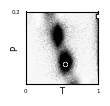

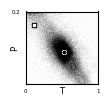

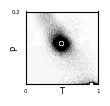

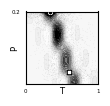

In [8]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

N_SYLL =  obj_3b.N_SYLL

# for i in [1]: # Change to N_SYLL for all syllables
for i in range(N_SYLL):
    plot_scatter_traj(obj = obj_3b, syll=i, day_i=0, day_f=60, every_nth_point=1, scatter_alpha=0.1, if_contour=False, contour_alpha=.5, heatmap=True, colorbar=False,
                      figsize=(1.2,1.2))

    plt.tight_layout()
    save_figure(f"landscape_3b_syll_{i}", save=save_figs)
    # save_figure(f"landscape_3b_syll_{i}", save=True, format="pdf", dpi=300)
    

In [9]:
chosen_syll = 0


Plotting syrinx landscape
Plotting syrinx landscape
Plotting syrinx landscape
Plotting syrinx landscape


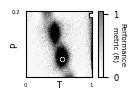

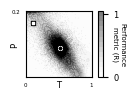

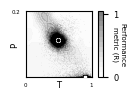

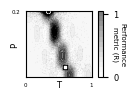

In [10]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

N_SYLL =  obj_3b.N_SYLL

# for i in [1]: # Change to N_SYLL for all syllables
for i in range(N_SYLL):
    plot_scatter_traj(obj = obj_3b, syll=i, day_i=0, day_f=60, every_nth_point=1, scatter_alpha=0.1, if_contour=False, contour_alpha=.5, heatmap=True, colorbar=True, legend=False,
                      figsize=(1.446,1.4))

    plt.tight_layout()
    save_figure(f"landscape_3b_syll_{i}_colorbar", save=save_figs)
    # save_figure(f"landscape_3b_syll_{i}_colorbar", save=True, format="svg", dpi=300)
    

Plotting syrinx landscape


/home/atharv/Documents/Github/Dual_Pathway_RL_songbird/dual_pathway_model/plotting_functions.py:666: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_16281/645098911.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Plotting syrinx landscape


/home/atharv/Documents/Github/Dual_Pathway_RL_songbird/dual_pathway_model/plotting_functions.py:666: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_16281/645098911.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Plotting syrinx landscape


/home/atharv/Documents/Github/Dual_Pathway_RL_songbird/dual_pathway_model/plotting_functions.py:666: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_16281/645098911.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Plotting syrinx landscape


/home/atharv/Documents/Github/Dual_Pathway_RL_songbird/dual_pathway_model/plotting_functions.py:666: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_16281/645098911.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


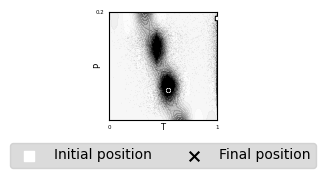

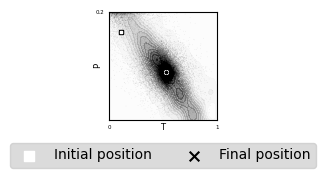

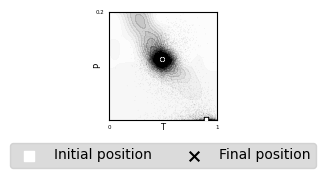

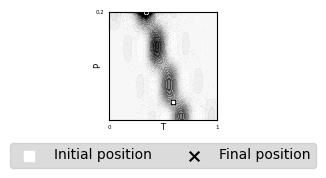

In [11]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

N_SYLL =  obj_3b.N_SYLL

# for i in [1]: # Change to N_SYLL for all syllables
for i in range(N_SYLL):
    plot_scatter_traj(obj = obj_3b, syll=i, day_i=0, day_f=60, every_nth_point=1, scatter_alpha=0.1, if_contour=False, contour_alpha=.5, heatmap=True, colorbar=False, legend=True,
                      figsize=(1.446,1.4))

    plt.tight_layout()
    save_figure(f"landscape_3b_syll_{i}_legend", save=save_figs)
    # save_figure(f"landscape_3b_syll_{i}_legend", save=True, format="pdf", dpi=300)
    

<!-- Alternate 2D plotting style -->

### C. Detailed trajectory plot for 1 syllable

In [12]:
# parameters = update_params(params_base,
#                            **{
#                                "params.LANDSCAPE": 1,
#                                "params.N_SYLL": 4
#                            } )
                           
# # running conditions
# N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
# TRIALS = N_DAILY_MOTIFS
# BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
# DAYS = parameters['params']['DAYS'] # days for learning
# N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
# if N_SYLL > 5 or N_SYLL < 1:
#     ValueError('Invalid number of syllables')
# RANDOM_SEED = RANDOM_SEED # 40
# ANNEALING = parameters['params']['ANNEALING'] # annealing 
# print(f'Random seed is {RANDOM_SEED}')

In [13]:
# # --------------------
# # Config
# # --------------------
# MODEL_DIR = "models"
# model_version = "model_3c" # 
# model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
# overwrite_model = True # whether to overwrite existing model or not
# save_model = False # whether to save model after running simulation or not
# # --------------------
# # Ensure models/ exists
# # --------------------
# os.makedirs(MODEL_DIR, exist_ok=True)

# # --------------------
# # Load / run / overwrite logic
# # --------------------
# if os.path.exists(model_path):
#     print(f"Model '{model_version}' already exists.")
#     if not overwrite_model:
#         print("Loading existing model...")
#         with open(model_path, "rb") as f:
#             obj_3c = pickle.load(f)
#         print(f"Loaded model '{model_version}'")
#     else:
#         print("Overwrite enabled. Re-running simulation and overwriting model...")
#         print(f"Model '{model_version}' not found. Running simulation...")
#         obj_3c = Environment(RANDOM_SEED, parameters, NN)
#         obj_3c.run(parameters)
#         if save_model:
#             with open(model_path, "wb") as f:
#                 pickle.dump(obj_3c, f)
#             print(f"Saved model '{model_version}'")
# else:
#     print(f"Model '{model_version}' not found. Running simulation...")
#     obj_3c = Environment(RANDOM_SEED, parameters, NN)
#     obj_3c.run(parameters)
#     if save_model:
#         with open(model_path, "wb") as f:
#             pickle.dump(obj_3c, f)
#         print(f"Saved model '{model_version}'")


Plotting syrinx landscape


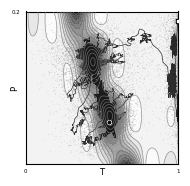

In [12]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

for i in [chosen_syll]: #range(N_SYLL):
# for i in range(N_SYLL):
    axs = plot_scatter_traj(obj = obj_3b, syll=i, day_i=0, day_f=60, every_nth_point=1, scatter_alpha=0.5,
                      if_contour=True, contour_alpha=.8, heatmap=True, plot_motor=True,
                    plot_smooth_traj=True, figsize=(2,2))  # To remove smoothened trajectory, set plot_smooth_traj=False

    plt.tight_layout()
    save_figure(f"landscape_3c_syll_{i}", save=save_figs)
    # save_figure(f"landscape_3c_syll_{i}", save=True, format="pdf", dpi=300)
    

/home/atharv/Documents/Github/Dual_Pathway_RL_songbird/dual_pathway_model/plotting_functions.py:875: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


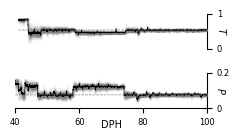

In [13]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

# for i in range(N_SYLL):
for i in [chosen_syll]:
    plot_output(obj_3b, i, skip_size=2, window_size=50, figsize=(2.5,1.5))
    plt.tight_layout()
    save_figure(f"landscape_3d_syll_{i}", save=save_figs)
    # save_figure(f"landscape_3d_syll_{i}", save=True, format="pdf", dpi=300)
    

In [14]:
actions = obj_3b.actions[:,:,chosen_syll,:].reshape(DAYS*TRIALS, 2)

Local Max Window: 3000 to 3400
Mean Tension: 0.08164855574724854
Mean Pressure: 0.5468903782792236
Global Max Window: -100 to -1
Mean Tension: 0.09292363855796397
Mean Pressure: -0.3686799380152464
Local Max Scaled:
Mean Tension: 0.5408242778736243
Mean Pressure: 0.15468903782792237
Global Max Scaled:
Mean Tension: 0.546461819278982
Mean Pressure: 0.06313200619847537
Difference in Tension: 0.00563754140535766
Difference in Pressure: -0.091557031629447


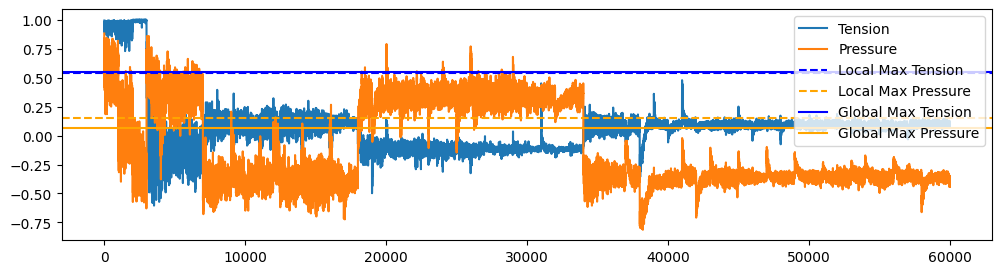

In [17]:


# locating local maxima
window_start_local = 3000
window_end_local = window_start_local +400
tension_local_max = np.mean(actions[window_start_local:window_end_local,0])
pressure_local_max = np.mean(actions[window_start_local:window_end_local,1])
print(f"Local Max Window: {window_start_local} to {window_end_local}")
print(f"Mean Tension: {tension_local_max}")
print(f"Mean Pressure: {pressure_local_max}")

# locating global maxima
window_start_global = -100
window_end_global = -1
tension_global_max = np.mean(actions[window_start_global:window_end_global,0])
pressure_global_max = np.mean(actions[window_start_global:window_end_global,1])
print(f"Global Max Window: {window_start_global} to {window_end_global}")
print(f"Mean Tension: {tension_global_max}")
print(f"Mean Pressure: {pressure_global_max}")

tension_local_max_scaled = (tension_local_max + 1) / 2
pressure_local_max_scaled = (pressure_local_max + 1) * 0.1
print(f"Local Max Scaled:")
print(f"Mean Tension: {tension_local_max_scaled}")
print(f"Mean Pressure: {pressure_local_max_scaled}")

tension_global_max_scaled = (tension_global_max + 1) / 2
pressure_global_max_scaled = (pressure_global_max + 1) * 0.1
print(f"Global Max Scaled:")
print(f"Mean Tension: {tension_global_max_scaled}")
print(f"Mean Pressure: {pressure_global_max_scaled}")

# difference between local and global maxima
tension_diff = tension_global_max_scaled - tension_local_max_scaled
pressure_diff = pressure_global_max_scaled - pressure_local_max_scaled
# scale tension -1,1 to 0,1 and pressure -1,1 to 0,0.2 
print(f"Difference in Tension: {tension_diff}")
print(f"Difference in Pressure: {pressure_diff}")

plt.figure(figsize=(12,3))
plt.plot(running_mean(actions[:,0]), label='Tension')
plt.plot(running_mean(actions[:,1]), label='Pressure')
plt.axhline(tension_local_max_scaled, color='blue', linestyle='--', label='Local Max Tension')
plt.axhline(pressure_local_max_scaled, color='orange', linestyle='--', label='Local Max Pressure')
plt.axhline(tension_global_max_scaled, color='blue', linestyle='-', label='Global Max Tension')
plt.axhline(pressure_global_max_scaled, color='orange', linestyle='-', label='Global Max Pressure')
plt.legend()
plt.show()

In [18]:
tension_local_max=.21
pressure_local_max=.44

tension_local_max_scaled = (tension_local_max + 1) / 2
pressure_local_max_scaled = (pressure_local_max + 1) * 0.1


print(f"Local Max Scaled:")
print(f"Mean Tension: {tension_local_max_scaled}")
print(f"Mean Pressure: {pressure_local_max_scaled}")


print(f"Global Max Scaled:")
print(f"Mean Tension: {tension_global_max_scaled}")
print(f"Mean Pressure: {pressure_global_max_scaled}")

# difference between local and global maxima
tension_diff = tension_global_max_scaled - tension_local_max_scaled
pressure_diff = pressure_global_max_scaled - pressure_local_max_scaled
# scale tension -1,1 to 0,1 and pressure -1,1 to 0,0.2 
print(f"Difference in Tension: {tension_diff}")
print(f"Difference in Pressure: {pressure_diff}")

Local Max Scaled:
Mean Tension: 0.605
Mean Pressure: 0.144
Global Max Scaled:
Mean Tension: 0.546461819278982
Mean Pressure: 0.06313200619847537
Difference in Tension: -0.05853818072101802
Difference in Pressure: -0.08086799380152462


/tmp/ipykernel_16281/342503576.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved as  Plots/landscape_3c_syllspec_0_global.png
Figure saved as  Plots/landscape_3c_syllspec_0_local.png


/tmp/ipykernel_16281/342503576.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


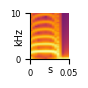

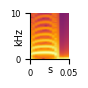

In [ ]:
# Example usage:
spec_syll = chosen_syll
# verify that the mapping is correct
if chosen_syll == 3: spec_syll = 0
if chosen_syll == 2: spec_syll = 3
if chosen_syll == 1: spec_syll = 2
if chosen_syll == 0: spec_syll = 1

spec_out = make_syrinx_spectrograms(syll_array=[spec_syll+1], random_seed=100, show=False, figsize_per_panel=(0.5, 0.6))
save_figure(f"landscape_3c_syllspec_{i}_global", save=save_figs)
# save_figure(f"landscape_3c_syllspec_{i}_global", save=True, format="png", dpi=300)
# save_figure(f"landscape_3c_syllspec_{i}_global", save=True, format="pdf", dpi=300)

spec_out = make_syrinx_spectrograms(syll_array=[spec_syll+1], random_seed=100, tension_offset=tension_diff, pressure_offset=pressure_diff, show=False, figsize_per_panel=(0.5, 0.6))
save_figure(f"landscape_3c_syllspec_{i}_local", save=save_figs)
# save_figure(f"landscape_3c_syllspec_{i}_local", save=True, format="png", dpi=300)
# save_figure(f"landscape_3c_syllspec_{i}_local", save=True, format="pdf", dpi=300)

# spec_single = make_syrinx_spectrograms(syll=3)

Figure saved as  Plots\landscape_3d_reward_syll_0.pdf


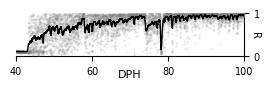

In [ ]:
%autoreload 2
from dual_pathway_model.plotting_functions import *

# for i in range(N_SYLL):
for i in [chosen_syll]:
    plot_reward(obj_3b, i, skip_size=10, window_size=300, figsize=(2.8,1))
    
    
    # save_figure(f"landscape_3d_reward_syll_{i}", save=True, format="pdf", dpi=300)

    save_figure(f"landscape_3d_reward_syll_{i}", save=save_figs)

### D. Performance over 4 syllables in a motif


syllable
[WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Figures/results/multi_syllable')]
Means
Figure saved as  Plots\robustness_3e_syll_0.pdf


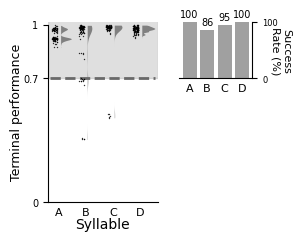

In [ ]:
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "results"

result_folders = find_subdirectories(results_dir, absolute=True)
selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    print(param_name)
    selected_folders.append((folder))
print(selected_folders)
terminal_performance = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)


terminal_performance['syllable'].shape, meta['syllable'].keys()
# Example call
plot_results_violin(
    terminal_performance["syllable"], 
    np.arange(terminal_performance["syllable"].shape[1]),  # dummy x values for violin plot
    big_xlabel="Syllable",
    xticklabels=['A', 'B', 'C', 'D'],
    print_success_rate=True,
    height_ratio=[2.8, 5],
    fig_size=(2.9,2.3),
    plot_legend=False,
    width_ratio=[6,4],
                        font_params={
                            'xlabel': {'fontsize': 10, 'labelpad': 0},
                            'xticklabels': {'fontsize': 8, 'rotation': 0},
                            'yticks': {'fontsize': 7},
                            'ylabel': {'fontsize': 9, 'rotation': 90, 'labelpad': 0},
                            'bar_xlabel': {'fontsize': 6, 'labelpad': 10},
                            'bar_xticklabels': {'fontsize': 8, 'rotation': 0},
                            'bar_yticks': {'fontsize': 6},
                            'bar_ylabel': {'fontsize': 8, 'rotation': 270, 'labelpad': 10},
                            'bar_height': {'fontsize': 7},
                            'legend': {'fontsize': 7}
                        }
)

save_figure(f"robustness_3e_syll_{i}", save=save_figs)
# save_figure(f"robustness_3e_syll_{i}", save=True, format="pdf", dpi=300)


### E. Different number of distractors
Modify this `plot_landscape` function to change the appearance. 

In [ ]:
# %autoreload 2
# from dual_pathway_model.functions import *
# from dual_pathway_model.directory_functions import *
# from dual_pathway_model.model import NN, Environment, params_base
# from dual_pathway_model.plotting_functions import *

Selected folders: [WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_N_DISTRACTORS')]
Terminal performance shape: (100, 5)
Meta keys: dict_keys(['parameter', 'section', 'seeds', 'shape', 'values'])
Wanted values: [5, 10, 40, 80]
Wanted indices: [0, 1, 3, 4]
Terminal performance for wanted indices shape: (100, 4)
Meta values for wanted indices: [5.0, 10.0, 40.0, 80.0]
Means
Figure saved as  Plots\robustness_3f_syll_0.pdf


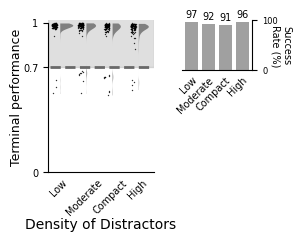

In [199]:



wanted_parameters = ["N_DISTRACTORS"]
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "../Robustness/results"

result_folders = find_subdirectories(results_dir, absolute=True)

selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    if param_name in wanted_parameters:
        selected_folders.append(folder)
print("Selected folders:", selected_folders)

terminal_performance = {}
meta = {}


for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)
print("Terminal performance shape:", terminal_performance['N_DISTRACTORS'].shape)
print("Meta keys:", meta['N_DISTRACTORS'].keys())
wanted_values = [5, 10, 40, 80]
wanted_indices = [i for i, val in enumerate(meta['N_DISTRACTORS']['values']) if val in wanted_values]
print("Wanted values:", wanted_values)
print("Wanted indices:", wanted_indices)
print("Terminal performance for wanted indices shape:", terminal_performance['N_DISTRACTORS'][:,wanted_indices].shape)
print("Meta values for wanted indices:", [meta['N_DISTRACTORS']['values'][i] for i in wanted_indices])

plot_results_violin(
    terminal_performance["N_DISTRACTORS"][:,wanted_indices], 
    [meta["N_DISTRACTORS"]["values"][i] for i in wanted_indices],
    big_xlabel="Density of Distractors",
    xticklabels=['Low', 'Moderate','Compact', 'High'],
    print_success_rate=True,
    height_ratio=[5, 5],
    fig_size=(2.9,2.3),
    plot_legend=False,
    width_ratio=[6,4],
                        font_params={
                            'xlabel': {'fontsize': 10, 'labelpad': 0},
                            'xticklabels': {'fontsize': 7, 'rotation': 45},
                            'yticks': {'fontsize': 7},
                            'ylabel': {'fontsize': 9, 'rotation': 90, 'labelpad': 0},
                            'bar_xlabel': {'fontsize': 6, 'labelpad': 10},
                            'bar_xticklabels': {'fontsize': 7, 'rotation': 45},
                            'bar_yticks': {'fontsize': 6},
                            'bar_ylabel': {'fontsize': 7, 'rotation': 270, 'labelpad': 10},
                            'bar_height': {'fontsize': 7},
                            'legend': {'fontsize': 7}
                        }
)


save_figure(f"robustness_3f_syll_{i}", save=save_figs)
save_figure(f"robustness_3f_syll_{i}", save=True, format="pdf", dpi=300)

In [ ]:



wanted_parameters = ["N_DISTRACTORS"]
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "../Robustness/results"

result_folders = find_subdirectories(results_dir, absolute=True)

selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    if param_name in wanted_parameters:
        selected_folders.append(folder)
print("Selected folders:", selected_folders)

terminal_performance = {}
meta = {}


for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)
print("Terminal performance shape:", terminal_performance['N_DISTRACTORS'].shape)
print("Meta keys:", meta['N_DISTRACTORS'].keys())
wanted_values = [5, 10, 40, 80]
wanted_indices = [i for i, val in enumerate(meta['N_DISTRACTORS']['values']) if val in wanted_values]
print("Wanted values:", wanted_values)
print("Wanted indices:", wanted_indices)
print("Terminal performance for wanted indices shape:", terminal_performance['N_DISTRACTORS'][:,wanted_indices].shape)
print("Meta values for wanted indices:", [meta['N_DISTRACTORS']['values'][i] for i in wanted_indices])

plot_results_violin(
    terminal_performance["N_DISTRACTORS"][:,wanted_indices], 
    [meta["N_DISTRACTORS"]["values"][i] for i in wanted_indices],
    big_xlabel="Density of Distractors",
    xticklabels=['Low', 'Moderate','Compact', 'High'],
    print_success_rate=True,
    height_ratio=[5, 5],
    fig_size=(2.9,2.3),
    plot_legend=True,
    width_ratio=[6,4],
                        font_params={
                            'xlabel': {'fontsize': 10, 'labelpad': 0},
                            'xticklabels': {'fontsize': 7, 'rotation': 45},
                            'yticks': {'fontsize': 7},
                            'ylabel': {'fontsize': 9, 'rotation': 90, 'labelpad': 0},
                            'bar_xlabel': {'fontsize': 6, 'labelpad': 10},
                            'bar_xticklabels': {'fontsize': 7, 'rotation': 45},
                            'bar_yticks': {'fontsize': 6},
                            'bar_ylabel': {'fontsize': 7, 'rotation': 270, 'labelpad': 10},
                            'bar_height': {'fontsize': 7},
                            'legend': {'fontsize': 7}
                        }
)


save_figure(f"robustness_3f_syll_{i}_legend", save=save_figs)
# save_figure(f"robustness_3f_syll_{i}_legend", save=True, format="pdf", dpi=300)

In [ ]:
raise NotImplementedError("Do we need next parts?")

NotImplementedError: Do we need next parts?

In [ ]:
# def plot_lansdcape(syll, force_landscape=False, landscape=1):
#     fig, axs = plt.subplots(figsize=(9, 9))
#     cmap = color_contour_bckg #LinearSegmentedColormap.from_list('white_to_black', ['white', 'rebeccapurple'])
#     levels_ = 50
#     def plot_artificial():
#         limit = obj.limit
#         x, y = np.linspace(-limit, limit, 50), np.linspace(-limit, limit, 50)
#         X, Y = np.meshgrid(x, y)
#         Z = obj.get_reward([X, Y], syll)
#         contour = axs.contourf(X, Y, Z, levels=levels_, cmap=cmap)
#         if if_contour:
#             axs.contour(X, Y, Z, levels=15, colors='k', linewidths=1, alpha=0.9)
#         # cbar = fig.colorbar(contour, ax=axs)
#         # cbar.set_label('Performance Metric (R)', fontsize=20, rotation = 270)
#         # cbar.ax.tick_params(labelsize=18)
#         # cbar.ax.set_yticks([0,1])

#         axs.set_xticks([-limit, 0, limit], [-1, 0, 1])
#         axs.set_yticks([-limit, 0, limit], [-1, 0, 1])

#     def plot_syrinx():
#         if obj.N_SYLL > 4:
#             raise ValueError('Only 4 syllables are available in the syrinx landscape')
#         obj.syrinx_contours = []
#         obj.syrinx_targets = []
#         for j in range(obj.N_SYLL):
#             base = np.load(f"contours/Syll{j+1}.npy")
#             Z, target = make_contour(base)
#             obj.syrinx_contours.append(Z)
#             obj.syrinx_targets.append(target)
#         obj.centers = np.array(obj.syrinx_targets)
#         obj.syrinx_contours = np.array(obj.syrinx_contours)
#         Z = obj.syrinx_contours[syll]
#         target_pos = obj.syrinx_targets[syll]
#         if if_contour:
#             axs.contour(Z.T, levels=15, extent=[-1, 1, -1, 1], colors='k', linewidths=1, alpha=1)
#         cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], levels=levels_)
#         # cbar = fig.colorbar(cs, ax = axs)
#         # cbar.set_label('Performance Metric (R)', fontsize=20, rotation = 270)
#         # cbar.ax.tick_params(labelsize=18)
#         # cbar.ax.set_yticks([0,1])
#         axs.set_xticks([-1, 1], [0, 1])
#         axs.set_yticks([-1,1], [0, 0.2])
#         # axs.scatter(target_pos[1], target_pos[0], s=100, c='green', marker='x', label='Target')

#     if not force_landscape:
#         if obj.LANDSCAPE == 0:
#             print("No force artificial landscape")
#             plot_artificial()
#         else:
#             plot_syrinx()
#     else:
#         if landscape == 0:
#             plot_artificial()
#         else:
#             plot_syrinx()

#     # axs.set_ylabel(r'$P_{\alpha}$', fontsize=22)
#     # axs.set_xlabel(r'$P_{\beta}$', fontsize=22)
#     axs.set_ylabel(r'$P$', fontsize=22)
#     axs.set_xlabel(r'$T$', fontsize=22)
#     axs.tick_params(labelsize=16)
#     axs.legend()
#     plt.tight_layout()
#     plt.show()

1
Random seed is 42
Model 'model_3e1' not found. Running simulation...


100%|██████████| 2/2 [00:00<00:00, 1986.88it/s]

Plotting artificial landscape


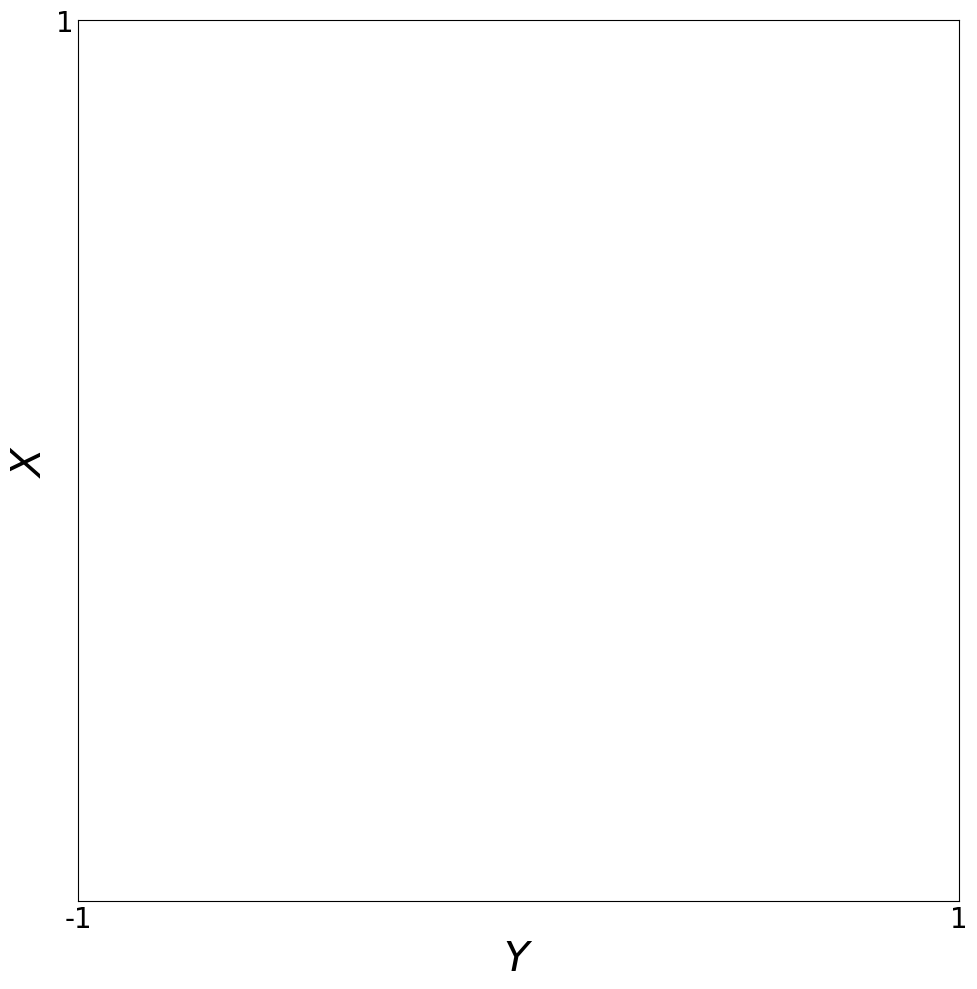

In [ ]:
# # load parameters from json file
# params_path = "params_3_5.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 1,
                               "params.DAYS": 2,
                               "params.TRIALS": 2,
                               "params.N_DISTRACTORS": 5
                           } )


# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 42
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING) 
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3e1" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3e1 = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3e1 = Environment(RANDOM_SEED, parameters, NN)
        obj_3e1.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3e1 = Environment(RANDOM_SEED, parameters, NN)
    obj_3e1.run(parameters)

plot_landscape_only(obj_3e1, syll=0)

1
Random seed is 42
Model 'model_3e2' not found. Running simulation...


100%|██████████| 2/2 [00:00<00:00, 1899.16it/s]

Plotting artificial landscape


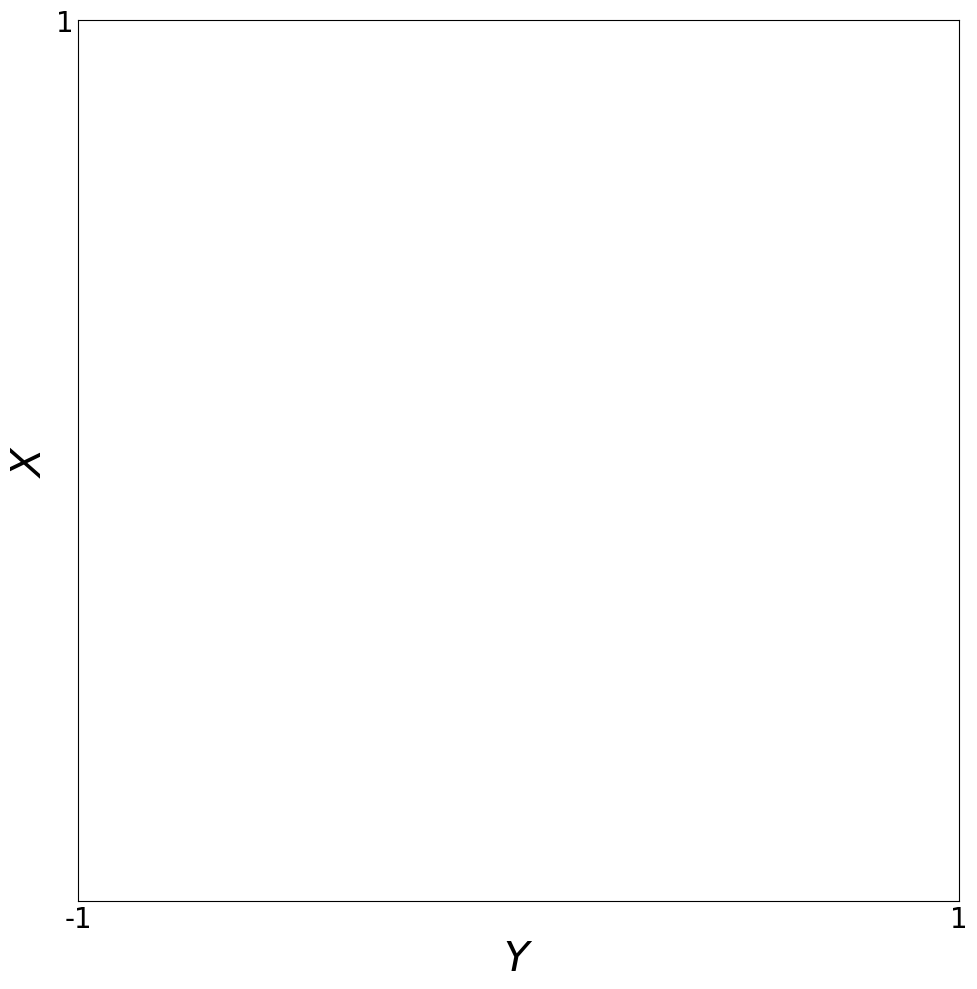

In [ ]:
# # load parameters from json file
# params_path = "params_3_5.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 1,
                               "params.DAYS": 2,
                               "params.TRIALS": 2,
                               "params.N_DISTRACTORS": 10
                           } )


# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 42
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING) 
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3e2" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3e2 = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3e2 = Environment(RANDOM_SEED, parameters, NN)
        obj_3e2.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3e2 = Environment(RANDOM_SEED, parameters, NN)
    obj_3e2.run(parameters)

plot_landscape_only(obj_3e2, syll=0)

1
Random seed is 42
Model 'model_3e3' not found. Running simulation...


100%|██████████| 2/2 [00:00<00:00, 783.10it/s]

Plotting artificial landscape


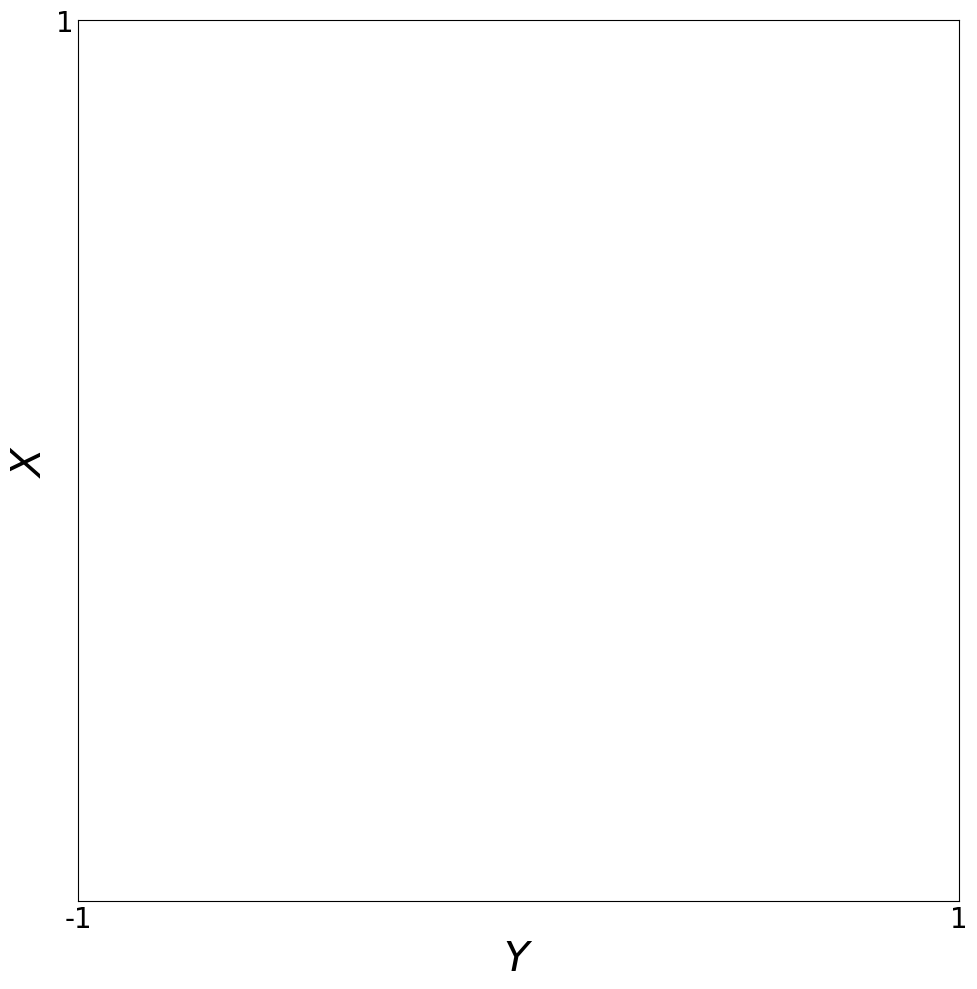

In [ ]:
# # load parameters from json file
# params_path = "params_3_5.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 1,
                               "params.DAYS": 2,
                               "params.TRIALS": 2,
                               "params.N_DISTRACTORS": 20
                           } )


# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 42
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING) 
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3e3" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3e3 = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3e3 = Environment(RANDOM_SEED, parameters, NN)
        obj_3e3.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3e3 = Environment(RANDOM_SEED, parameters, NN)
    obj_3e3.run(parameters)

plot_landscape_only(obj_3e3, syll=0)

1
Random seed is 42
Model 'model_3e4' not found. Running simulation...


100%|██████████| 2/2 [00:00<00:00, 793.25it/s]

Plotting artificial landscape


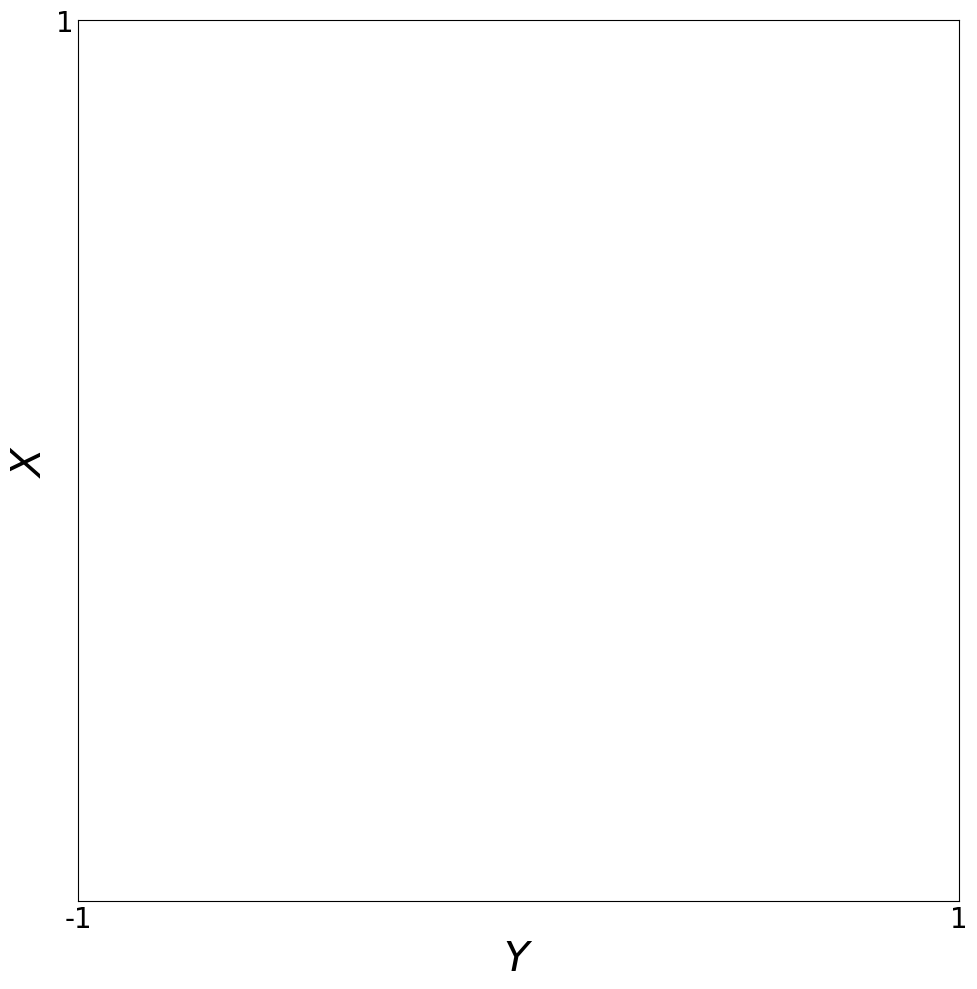

In [ ]:
# # load parameters from json file
# params_path = "params_3_5.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 1,
                               "params.DAYS": 2,
                               "params.TRIALS": 2,
                               "params.N_DISTRACTORS": 50
                           } )


# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 42
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING) 
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3e4" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3e4 = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3e4 = Environment(RANDOM_SEED, parameters, NN)
        obj_3e4.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3e4 = Environment(RANDOM_SEED, parameters, NN)
    obj_3e4.run(parameters)

plot_landscape_only(obj_3e4, syll=0)

<!-- ### Spectrograms of maxima's
Change the value of P_alpha and T_beta from 0,0 to something else -->

In [ ]:
# P_alpha, T_beta = 0.5, 0.3

In [ ]:
# np.random.seed(100)
# # Parameters
# gamma = 12000 

# duration = 0.050 #s
# dt = 1/44100 #s  #* 0.1 #1.e-4

# Amp = 10

# # Trachea parameters
# r=-0.9
# v=350*100
# L=1.9
# tau_0=2*L/v # Propagation time along trachea
# tau_n=int(tau_0/dt)
# # ks = np.linspace(0.16,0.52, 10)
# # ps = np.linspace(1852,2084, 10)

# # Track position and velocity 
# nt = int(duration/dt)
# X = np.zeros(nt)          # Labial position
# Y = np.zeros(nt)          # Velocity

# def sigmoid(x):
#       return 1 / (1 + np.exp(-x))

# def syrinxODE(t, y):
#     ''' ODEs used in Amador paper'''
    
#     y0, y1 = y
#     dydt = [y1,
#          -Pressure(t)*(gamma**2) - Tension(t)*(gamma**2)*y0 - (gamma**2)*(y0**3) - gamma*(y0**2)*y1 + (gamma**2)*(y0**2) - gamma*y0*y1
#            ]
#     return dydt

# # RC4
# # syllable 1
# syllable_array = [1]
# P_t_list = []  # <— add before the syllable loop




# for syllable in syllable_array:
#     if syllable == 1:
#         def Tension(t):
#             """ Generalised exponential waveform """
#             return   .3 - .2*np.exp(-200*t) -.00001 * np.exp(200*t) + T_beta

        
#         def Pressure(t):
#             """ Constant """
#             return 0.04*np.sin((duration/2 + t)*np.pi*10) + 0.05 + P_alpha
#     # RC5 - test
#     elif syllable == 2:
#         # syllable 2
#         def Tension(t):
#             """ Generalised exponential waveform """
#             Tc = 1#2/3
#             return   .3 - .2*np.exp(-Tc*3*100*t) -.00001 * np.exp(Tc*3*100*t) + T_beta

#         def Pressure(t):
#             """ Constant """
#             tp = 0.2
#             return tp*np.sin((duration/2 + t)*np.pi*10) + 0.05 + P_alpha
#     elif syllable == 3:
#         # syllable 3
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             scale = 1
#             if isinstance(t, float):
#                 if t <= duration*scale/2: 
#                     return 5*np.sin(t*np.pi*40/scale) + 0.6 + T_beta # old amp 0.1
#                 elif t <= duration*scale: 
#                     return 10*np.sin((t-duration*scale/2)*np.pi*15/scale) + 0.6 + T_beta# old amp 0.2
#                 else: 
#                     return 0.0 + 0*t + T_beta
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 5*np.sin(t*np.pi*40/scale) + 0.6 + T_beta# old amp 0.1
#                 Tension2 = 10*np.sin(t*np.pi*15/scale) + 0.6 + T_beta# old amp 0.2
#                 Tension3 = 0.0 + 0*t + T_beta
#                 return np.concatenate((Tension1[:int(np.ceil(t.size*scale/2))], Tension2[:int(t.size*scale-t.size*scale/2)], Tension3[:int(t.size-t.size*scale)]))        
        
#         def Pressure(t):
#             """ Pressure = 0.02 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 2  + P_alpha # old amp 0.16
#     elif syllable == 4:
#         # syllable 4
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             scale = 0.4
#             if isinstance(t, float):
#                 if t <= duration*scale: 
#                     return 0.8*np.sin(t*np.pi*20/scale) + 0.6 + T_beta # old amp 0.1
#                 else: 
#                     return t*0 + 0.6 + T_beta # old amp 0.2
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 0.8*np.sin(t*np.pi*20/scale) + 0.6 + T_beta # old amp 0.1
#                 Tension2 = t* 0 + 0.6 + T_beta # old amp 0.2
#                 return np.concatenate((Tension1[:int(np.ceil(t.size*scale))], Tension2[:int(t.size-t.size*scale)]))
            
#         def Pressure(t):
#             """ Pressure = 0.02 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.01 + P_alpha
            
#     elif syllable == 5:
#         # syllable 5
#         def Tension(t):
#             """ Tension = 0.2 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.2
            
#         def Pressure(t):
#             """ Pressure = 0.1 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.1
#     elif syllable == 6:
#         # syllable 6
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             if isinstance(t, float):
#                 if t <= duration/2: return 0.1*np.sin(t*np.pi*40) + 0.6
#                 else: return 0.2*np.sin((t-duration/2)*np.pi*15) + 0.6
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 0.1*np.sin(t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(t*np.pi*15) + 0.6
#                 return np.concatenate((Tension1[:int(np.ceil(t.size/2))], Tension2[:int(t.size-t.size/2)]))
            
#         def Pressure(t):
#             """ Pressure = 0.01*np.sin(sin_t*np.pi*2*100) + 0.02 """
#             return 0.01*np.sin(t*np.pi*2*100) + 0.02
        

#     solution = solve_ivp(syrinxODE, [0, duration], [1, 1], method = "RK45", t_eval = np.linspace(0,duration,nt), rtol = 1e-8, atol = 1e-8)
#     # Extract labial position (X) and velocity (Y)
#     X = solution['y'][0]
#     Y = solution['y'][1]
#     # Transform into song
#     time_x = np.linspace(0, duration, nt)
#     song = Amp * Pressure(time_x) * Y
#     ## Trachea from Darshan, et. al. https://doi.org/10.1038/ncomms15415

#     # Input to trachea = output of syrinx
#     y0 = song.T

#     # To generate pressure output from trachea
#     P_i=np.zeros((len(y0)))

#     # See Fig 1 in Amador paper. Round-about way to implement that.
#     Buffer = queue.Queue()
#     for i in np.arange(tau_n):
#         Buffer.put(np.random.random())

#     for i in np.arange(len(y0)):
#         P_i[i] = y0[i] - r*Buffer.get();      
#         # update_buffer
#         Buffer.put(P_i[i])

#     # P_tr from P_in (ref Amador paper)
#     BufferB=np.zeros((tau_n))
#     P_tmp= np.concatenate((BufferB, P_i))
#     P_t=(1-r)*P_tmp[:-tau_n]
#     # ... inside your syllable loop, after computing P_t ...
#     P_t_list.append(P_t.copy())
#     time_x = np.linspace(0, duration, nt)

In [ ]:
# for i in range(len(syllable_array)):
#     P_t = P_t_list[i]
#     figure, ax = plt.subplots(1)

#     (spectrumP, freqsP, t, im) = plt.specgram(P_t, Fs=1/dt, NFFT=256, noverlap=128, xextent=[0,.05], cmap='inferno')
#     im


#     # ax.set_ylabel('Frequency (kHz)', fontsize=30)
#     # ax.set_xlabel('Time (s)', fontsize=30)
#     # ax.set_title(f'Syllable:{syllable}', fontsize=30)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['bottom'].set_visible(False)
#     ax.set_ylim(0,10000)
#     ax.set_xlim(0,.05)
#     ax.set_xticklabels([])
#     ax.set_yticks([0, 10000])
#     ax.set_yticklabels([0, 10])
#     ax.set_yticklabels([])
#     ax.tick_params(labelsize=15)

#     figure.set_size_inches(4, 6, forward=True)


#     plt.plot()
#     plt.show()